##Libraries used

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

##Loading the dataset + descriptive stats

In [16]:
#Load the videogame data excell file
data = pd.read_csv("Videogamedata.csv")
print(data.head())

       gameId  blueWins  blueWardsPlaced  blueWardsDestroyed  blueFirstBlood  \
0  4519157822         0               28                   2               1   
1  4523371949         0               12                   1               0   
2  4521474530         0               15                   0               0   
3  4524384067         0               43                   1               0   
4  4436033771         0               75                   4               0   

   blueKills  blueDeaths  blueAssists  blueEliteMonsters  blueDragons  ...  \
0          9           6           11                  0            0  ...   
1          5           5            5                  0            0  ...   
2          7          11            4                  1            1  ...   
3          4           5            5                  1            0  ...   
4          6           6            6                  0            0  ...   

   redTowersDestroyed  redTotalGold  redAvgLevel  

Accuracy: 0.7176113360323887
              precision    recall  f1-score   support

           0       0.72      0.72      0.72       990
           1       0.72      0.71      0.72       986

    accuracy                           0.72      1976
   macro avg       0.72      0.72      0.72      1976
weighted avg       0.72      0.72      0.72      1976



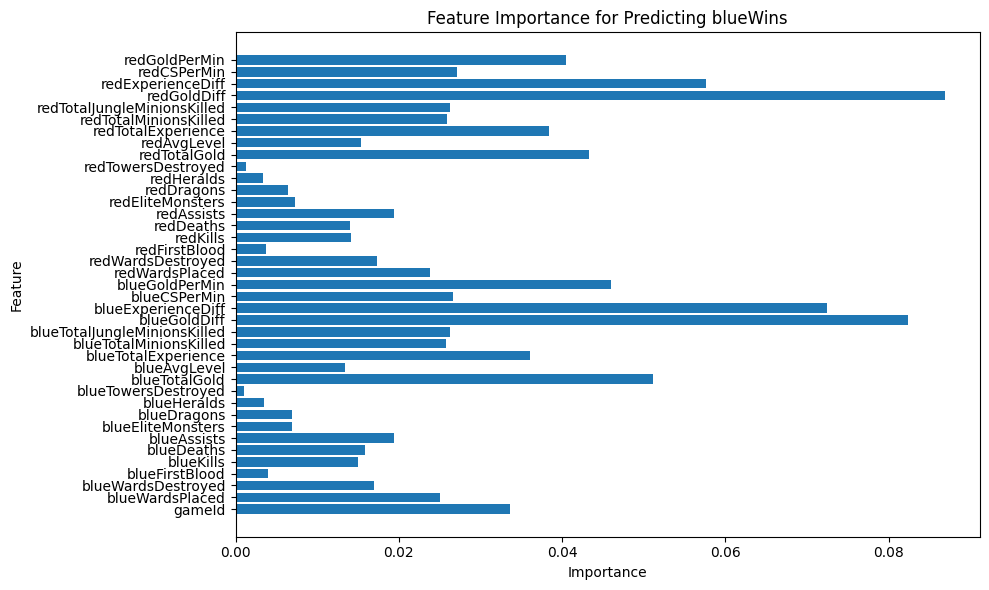

In [7]:
#Split into features and target
X = data.drop(columns=['blueWins'])        # explanatory variables
y = data['blueWins']                       # target variable

#Train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,         # 20% for testing
    random_state=42,       # reproducible split
    stratify=y             # keep class balance
)

#Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

#Predictions
y_pred = rf_model.predict(X_test)

#Accuracy & report
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Feature importances
feature_importances = rf_model.feature_importances_
feature_names = X.columns  # use your X’s column names

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importances)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance for Predicting blueWins")
plt.tight_layout()
plt.show()

Model performance on test set:

Logistic Regression  accuracy: 0.716
SVM (RBF kernel)     accuracy: 0.716
k-NN                 accuracy: 0.691
Naive Bayes          accuracy: 0.717
Decision Tree        accuracy: 0.643
Random Forest        accuracy: 0.717
Gradient Boosting    accuracy: 0.720


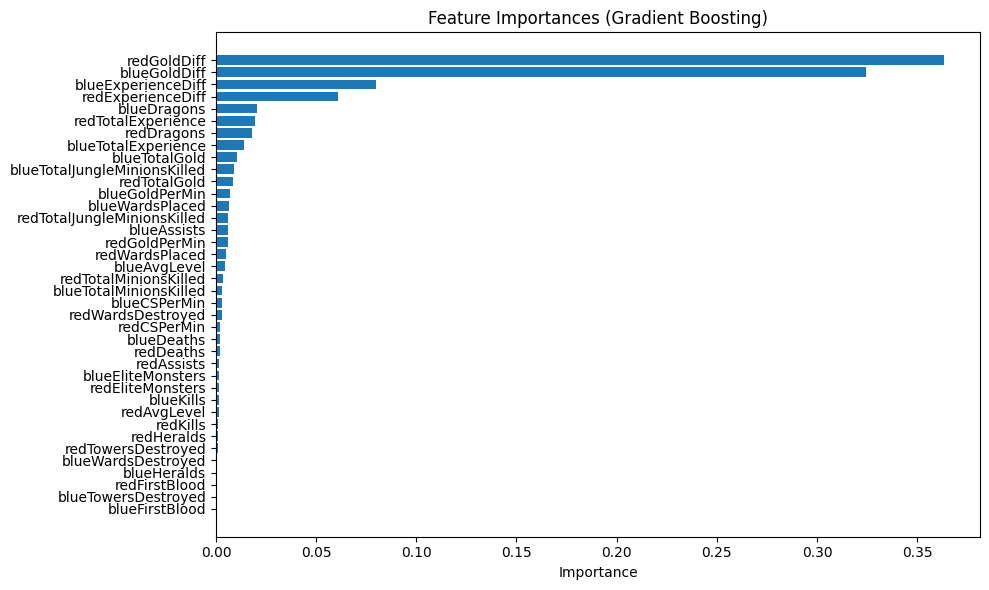

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Load your data
data = pd.read_csv("Videogamedata.csv")

# Drop IDs if present (to avoid leakage)
X = data.drop(columns=['blueWins', 'gameId'], errors='ignore')
y = data['blueWins']

# 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale features for models that need it
# (SVM, k-NN, LogisticRegression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF kernel)": SVC(),
    "k-NN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# 5. Evaluate each model
print("Model performance on test set:\n")
for name, model in models.items():
    # use scaled data for models that benefit from it
    if name in ["Logistic Regression", "SVM (RBF kernel)", "k-NN"]:
        model.fit(X_train_scaled, y_train)
        score = model.score(X_test_scaled, y_test)
    else:
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
    print(f"{name:20s} accuracy: {score:.3f}")




# Dive a little deeper into gradient boosting
# Get the trained Gradient Boosting model from your dict
gb_model = models["Gradient Boosting"]

# Get feature importances
gb_importances = gb_model.feature_importances_
gb_sorted_idx = np.argsort(gb_importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(gb_sorted_idx)), gb_importances[gb_sorted_idx], align='center')
plt.yticks(range(len(gb_sorted_idx)), [X.columns[i] for i in gb_sorted_idx])
plt.xlabel("Importance")
plt.title("Feature Importances (Gradient Boosting)")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

##Testing neural network
# Define a neural network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers with 64 and 32 neurons
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

# Train
mlp.fit(X_train_scaled, y_train)

# Evaluate
y_pred = mlp.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6629554655870445
              precision    recall  f1-score   support

           0       0.67      0.65      0.66       990
           1       0.66      0.67      0.67       986

    accuracy                           0.66      1976
   macro avg       0.66      0.66      0.66      1976
weighted avg       0.66      0.66      0.66      1976



c:\Users\semmi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
